# Pipeline C — Cross-attention BEV fusion

`BEV_camera` (stereo-splat) + `BEV_lidar` (PointPillars) →
**windowed cross-attention + near/far gate** → CenterPoint head.

Drop-in swap of the fusion block vs. Pipeline A (same branches, same head):

| step | module | role |
|------|--------|------|
| 1 | `cam_proj` / `lid_proj` | 1×1 conv → shared embedding E |
| 2 | `_WindowCrossAttention` | camera tokens query LiDAR within 8×8 windows |
| 3 | `gate` | per-cell σ; near cells (g≈0)→stereo, far (g≈1)→LiDAR attn |
| 4 | `post_conv` | local spatial context (mirrors A's conv stack) |

Each section **calls the project `.py` modules** — no heavy code lives here.
Stages not yet built (`train.py`, `evaluation.py`) are left empty as TODO.

## 1. Imports

In [1]:
import numpy as np
import torch

# Project modules — the implementation stays inside the .py files (6-file layout:
# data / evaluation / globals / network / train / utils).
import data, utils
import globals as G                       # shared BEV grid + channel contract (single source)
from data import Py123dDataset
from network import (
    PillarConfig, PointPillarsBranch, StereoBEVBranch,  # Stage A branches
    CrossAttentionFusion, BEVDetector, BEVFusionConfig, # fusion + head
    PipelineC,                                           # end-to-end convenience class
    describe,
)

# Stages still to implement — imported as placeholders.
import train        # noqa: F401  (empty: training loop TODO)
import evaluation   # noqa: F401  (empty: AV2 distance-AP / CDS eval TODO)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

/home/vittorio/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/vittorio/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


device: cuda


/home/vittorio/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Globals

In [2]:
# globals.py is the single source of truth for the shared BEV grid + channel
# contract. Every branch config (PillarConfig, MonoBEVConfig, StereoBEVConfig)
# defaults to it, so the grid can't drift between branches. Indexing: ix*ny+iy.
print("grid_size (nx, ny):", G.GRID_SIZE, "| x_range:", G.X_RANGE, "| y_range:", G.Y_RANGE)
print("channels — camera:", G.CAMERA_BEV_CHANNELS, "| lidar:", G.LIDAR_BEV_CHANNELS,
      "| fused:", G.FUSED_CHANNELS, "| num_classes:", G.NUM_CLASSES)

# Pipeline C attention hyper-params (can override in CrossAttentionFusion constructor).
WIN_H, WIN_W = 8, 8   # window size; n = 64 tokens/window on the 200×160 grid
NUM_HEADS    = 4       # must divide G.FUSED_CHANNELS
print(f"cross-attention: win={WIN_H}×{WIN_W}, heads={NUM_HEADS}, "
      f"tokens/window={WIN_H*WIN_W}")

grid_size (nx, ny): (200, 160) | x_range: (0.0, 50.0) | y_range: (-20.0, 20.0)
channels — camera: 64 | lidar: 128 | fused: 128 | num_classes: 3
cross-attention: win=8×8, heads=4, tokens/window=64


## 3. Utils

In [3]:
# Visualisation helpers live in utils.py (LiDAR density BEV + GT boxes, point
# cloud, stereo pair, frustum, voxels, clusters, pipeline debug maps).
import utils
print([f for f in dir(utils) if f.startswith("visualize_")])
# e.g. utils.visualize_bev(sample)              -> ego-frame boxes over a LiDAR BEV
#      utils.visualize_pipeline_debug(pipeline) -> per-stage BEV maps (requires debug=True)

['visualize_attention_gate', 'visualize_bev', 'visualize_clusters', 'visualize_detections', 'visualize_encoded_targets', 'visualize_evaluation', 'visualize_frustum', 'visualize_images', 'visualize_pipeline_debug', 'visualize_pointcloud', 'visualize_stereo_bev_diagnostic', 'visualize_voxels']


## 4. Data

In [4]:
# data.py loads Argoverse 2 through py123d and assembles one StereoSample / frame.
dataset = Py123dDataset(split_names=["av2-sensor_val"], max_num_scenes=1)
frame   = dataset.get_frame(0, dataset.scenes[0].number_of_history_iterations + 13)
sample  = frame.to_stereo_sample()
print(sample)

# GT boxes: global frame (for 2D projection) + ego frame (for BEV target encoding).
# See data.boxes_global_to_ego / assert_boxes_in_sensor_range.
print("boxes_3d (global):", sample.boxes_3d.shape,
      "| boxes_3d_ego:", sample.boxes_3d_ego.shape)
# utils.visualize_images(sample); utils.visualize_pointcloud(sample)

DEBUG: PY123D_DATA_ROOT resolved to /home/vittorio/datasets/av2
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['av2-sensor_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=1, shuffle=False)
StereoSample(dataset='av2-sensor', log='02678d04-cc9f-3148-9f95-1ba66347dff9', iter=13, boxes_3d=27, boxes_2d=7, lidar_pts=93509, depth=no)
boxes_3d (global): (27, 10) | boxes_3d_ego: (27, 10)


## 5. Network

### 5a. Stage A — BEV branches (identical to Pipelines A / B)

In [5]:
# --- Stage A: the two BEV branches emit grid-aligned (C, nx, ny) maps ----------
lidar_branch  = PointPillarsBranch(PillarConfig()).to(DEVICE).eval()
camera_branch = StereoBEVBranch().to(DEVICE).eval()

# PointPillars wants (N, 4) = [x, y, z, intensity], so append the reflectance.
pts_lidar = np.concatenate(
    [sample.lidar_xyz, sample.lidar_features["intensity"][:, None]], axis=1
).astype(np.float32)

with torch.no_grad():
    bev_lidar  = lidar_branch(pts_lidar, device=DEVICE)   # (C_lidar, nx, ny)
    bev_camera = camera_branch(sample, device=DEVICE)      # (C_cam,   nx, ny)

print("BEV_lidar:", tuple(bev_lidar.shape), "| BEV_camera:", tuple(bev_camera.shape))

BEV_lidar: (128, 200, 160) | BEV_camera: (64, 200, 160)


### 5b. Stage 4 — CrossAttentionFusion + CenterPoint head

In [6]:
# Build the Pipeline-C detector: same BEVDetector API as A, but with
# fusion_cls=CrossAttentionFusion. from_bev_maps reads the channel contract
# straight off the Stage A tensors — the grid can't drift between runs.
detector = BEVDetector.from_bev_maps(
    bev_camera, bev_lidar,
    num_classes=3,
    fusion_cls=CrossAttentionFusion,          # <-- the only change vs Pipeline A
).to(DEVICE).eval()

describe(detector)   # prints channel contract + parameter counts

with torch.no_grad():
    out = detector(bev_camera, bev_lidar)

print({k: tuple(v.shape) for k, v in out.items()})
#   heatmap (1, num_classes, nx, ny)  +  offset (1, 2, nx, ny)

# TODO (target encoder): rasterize sample.boxes_3d_ego[:, :2] + class into the
#   same (num_classes, nx, ny) heatmap + (2, nx, ny) offset targets to train against.

BEV fusion contract — Stage A must emit, on the shared grid:
  camera BEV : (B, 64, 200, 160)
  lidar  BEV : (B, 128, 200, 160)
  fused      : (B, 128, 200, 160)
  head out   : heatmap (B, 3, 200, 160) + offset (B, 2, 200, 160)
parameters:
  fusion : 420,613
  head   : 74,181
  total  : 494,794
{'heatmap': (1, 3, 200, 160), 'offset': (1, 2, 200, 160)}


### 5c. End-to-end convenience — PipelineC

`PipelineC` wraps both branches + the cross-attention detector in one module:
`pipeline(sample, device)` → `{heatmap, offset}`.  
Enable `debug=True` to capture BEV maps at every stage.

In [7]:
# PipelineC sets fusion_cls = CrossAttentionFusion at the class level.
# Identical interface to PipelineA — only the fusion internals differ.
pipeline = PipelineC(num_classes=3).to(DEVICE)
pipeline.debug = True   # store intermediates after forward

with torch.no_grad():
    out_pipe = pipeline(sample, device=DEVICE)

print({k: tuple(v.shape) for k, v in out_pipe.items()})

# Intermediates: bev_camera, bev_lidar, fused, heatmap, offset — all (C, nx, ny).
print("intermediates:", {k: tuple(v.shape) for k, v in pipeline.intermediates.items()})

# Full pipeline debug panels (requires matplotlib):
# utils.visualize_pipeline_debug(pipeline)

{'heatmap': (1, 3, 200, 160), 'offset': (1, 2, 200, 160)}
intermediates: {'bev_camera': (64, 200, 160), 'bev_lidar': (128, 200, 160), 'fused': (128, 200, 160), 'heatmap': (3, 200, 160), 'offset': (2, 200, 160)}


### 5d. Attention gate visualisation

The gate map `g ∈ (0, 1)` is a per-cell scalar produced by a lightweight 1×1 conv
on `cat(cam_proj, lid_proj)`.  Near cells (dense stereo) converge to **g ≈ 0**
(trust camera); far cells (sparse stereo, reliable LiDAR beams) converge to
**g ≈ 1** (trust LiDAR attention).  Plot it to verify the model learns the
expected near/far geometry.

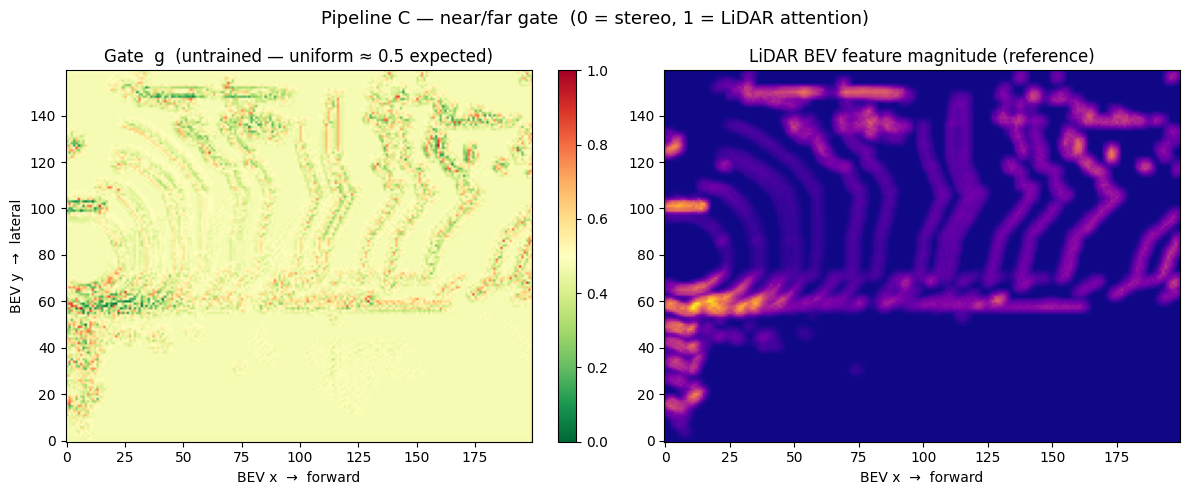

gate stats — min: 0.0180  max: 0.9771  mean: 0.4778


In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Extract the gate map directly from the CrossAttentionFusion internals ----
# We run a partial forward (cam_proj + lid_proj + gate) to get g without the
# full attention pass — useful for quick ablations or visual sanity checks.
fusion = pipeline.detector.fusion   # CrossAttentionFusion instance

bev_cam_b = bev_camera.unsqueeze(0).to(DEVICE)   # add batch dim
bev_lid_b = bev_lidar.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    cam_e = fusion.cam_proj(bev_cam_b)                          # (1, E, nx, ny)
    lid_e = fusion.lid_proj(bev_lid_b)                          # (1, E, nx, ny)
    gate  = fusion.gate(torch.cat([cam_e, lid_e], dim=1))       # (1, 1, nx, ny)

gate_np = gate[0, 0].cpu().numpy()   # (nx, ny)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Pipeline C — near/far gate  (0 = stereo, 1 = LiDAR attention)",
             fontsize=13)

# Gate map
im = axes[0].imshow(
    gate_np.T, origin="lower", cmap="RdYlGn_r",
    vmin=0, vmax=1, aspect="auto",
)
axes[0].set_title("Gate  g  (untrained — uniform ≈ 0.5 expected)")
axes[0].set_xlabel("BEV x  →  forward")
axes[0].set_ylabel("BEV y  →  lateral")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# LiDAR density BEV for spatial reference
lid_density = bev_lidar.cpu().norm(dim=0).numpy()   # crude per-cell magnitude
axes[1].imshow(lid_density.T, origin="lower", cmap="plasma", aspect="auto")
axes[1].set_title("LiDAR BEV feature magnitude (reference)")
axes[1].set_xlabel("BEV x  →  forward")

plt.tight_layout()
plt.show()

print(f"gate stats — min: {gate_np.min():.4f}  max: {gate_np.max():.4f}"
      f"  mean: {gate_np.mean():.4f}")

### 5e. Pipeline A vs C — fused BEV comparison

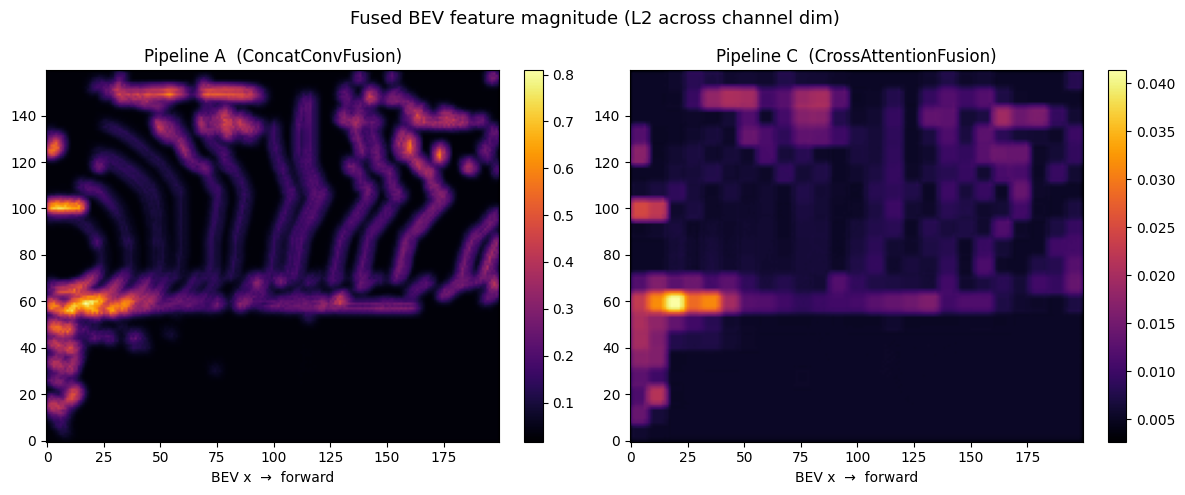

In [9]:
from network import ConcatConvFusion

# Build Pipeline A detector (same channel contract, concat+conv fusion).
detector_a = BEVDetector.from_bev_maps(
    bev_camera, bev_lidar, num_classes=3,
    fusion_cls=ConcatConvFusion,
).to(DEVICE).eval()

with torch.no_grad():
    fused_a = detector_a.fusion(bev_camera, bev_lidar)[0].cpu()   # (E, nx, ny)
    fused_c = detector.fusion(bev_camera, bev_lidar)[0].cpu()     # (E, nx, ny)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Fused BEV feature magnitude (L2 across channel dim)", fontsize=13)

for ax, feat, title in zip(
    axes,
    [fused_a, fused_c],
    ["Pipeline A  (ConcatConvFusion)", "Pipeline C  (CrossAttentionFusion)"],
):
    mag = feat.norm(dim=0).numpy()
    im  = ax.imshow(mag.T, origin="lower", cmap="inferno", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("BEV x  →  forward")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Train

targets — heatmap: (1, 3, 200, 160) | offset: (1, 2, 200, 160)
positive cells (GT centres): 3


/home/vittorio/Desktop/AIRO/CV/stereo-lidar-perception/train.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total, {"heatmap": float(hm_loss), "offset": float(off_loss)}


overfit loss: 179.938 → 1.985


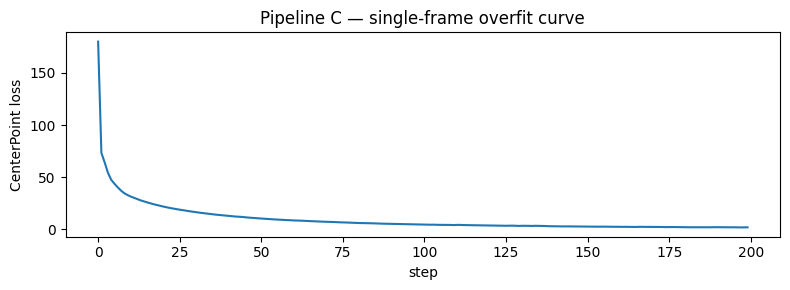

In [10]:
# ── 1. Single-frame overfit (sanity check: does the loop learn?) ──────────
# encode_sample builds the (1, num_classes, nx, ny) heatmap + (1, 2, nx, ny)
# offset targets from the ego-frame 3-D boxes in `sample`.
from train import TargetEncoder, encode_sample, overfit_pipeline_c

encoder  = TargetEncoder()
tgt_hm, tgt_off = encode_sample(sample, encoder)
print("targets — heatmap:", tuple(tgt_hm.shape), "| offset:", tuple(tgt_off.shape))
print("positive cells (GT centres):", int(tgt_hm.eq(1).sum()))

pipeline_overfit = PipelineC(num_classes=3,
                              stereo_cache_root=None)  # use live SGBM for the overfit

history = overfit_pipeline_c(
    pipeline_overfit, sample, tgt_hm, tgt_off,
    steps=200, lr=5e-4, device=DEVICE,
)
print(f"overfit loss: {history[0]:.3f} → {history[-1]:.3f}")

# ── loss curve ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history)
ax.set_xlabel("step");  ax.set_ylabel("CenterPoint loss")
ax.set_title("Pipeline C — single-frame overfit curve")
fig.tight_layout();  plt.show()

# ── 2. Multi-frame training (scene split → train / val) ──────────────────────
# Uncomment and set stereo_cache_root to run the full training loop.
# from train import split_frames, train_pipeline_c
#
# STEREO_CACHE = "data/stereo_cache"   # path built by data.precompute_stereo_inputs
# CKPT         = "checkpoints/pipeline_c_best.pt"
#
# dataset_full   = Py123dDataset(split_names=["av2-sensor_val"], max_num_scenes=5)
# train_frames, val_frames = split_frames(dataset_full, val_scenes=1)
#
# pipeline = PipelineC(num_classes=3, stereo_cache_root=STEREO_CACHE)
# history  = train_pipeline_c(
#     pipeline, train_frames, val_frames,
#     epochs=10, lr=5e-4, accum=4,
#     ckpt_path=CKPT,
#     device=DEVICE,
# )
# # plot
# fig, ax = plt.subplots(figsize=(8, 3))
# ax.plot(history["train"], label="train")
# ax.plot(history["val"],   label="val")
# ax.legend();  ax.set_xlabel("epoch");  ax.set_ylabel("CenterPoint loss")
# ax.set_title("Pipeline C — multi-frame training")
# fig.tight_layout();  plt.show()


## 7. Test

✓ gradient check passed — attention + gate layers all receive gradients.
GT centres: 3  |  decoded (score≥0.3): 3
Figure saved → docs/img/pipeline_c_test_output.png


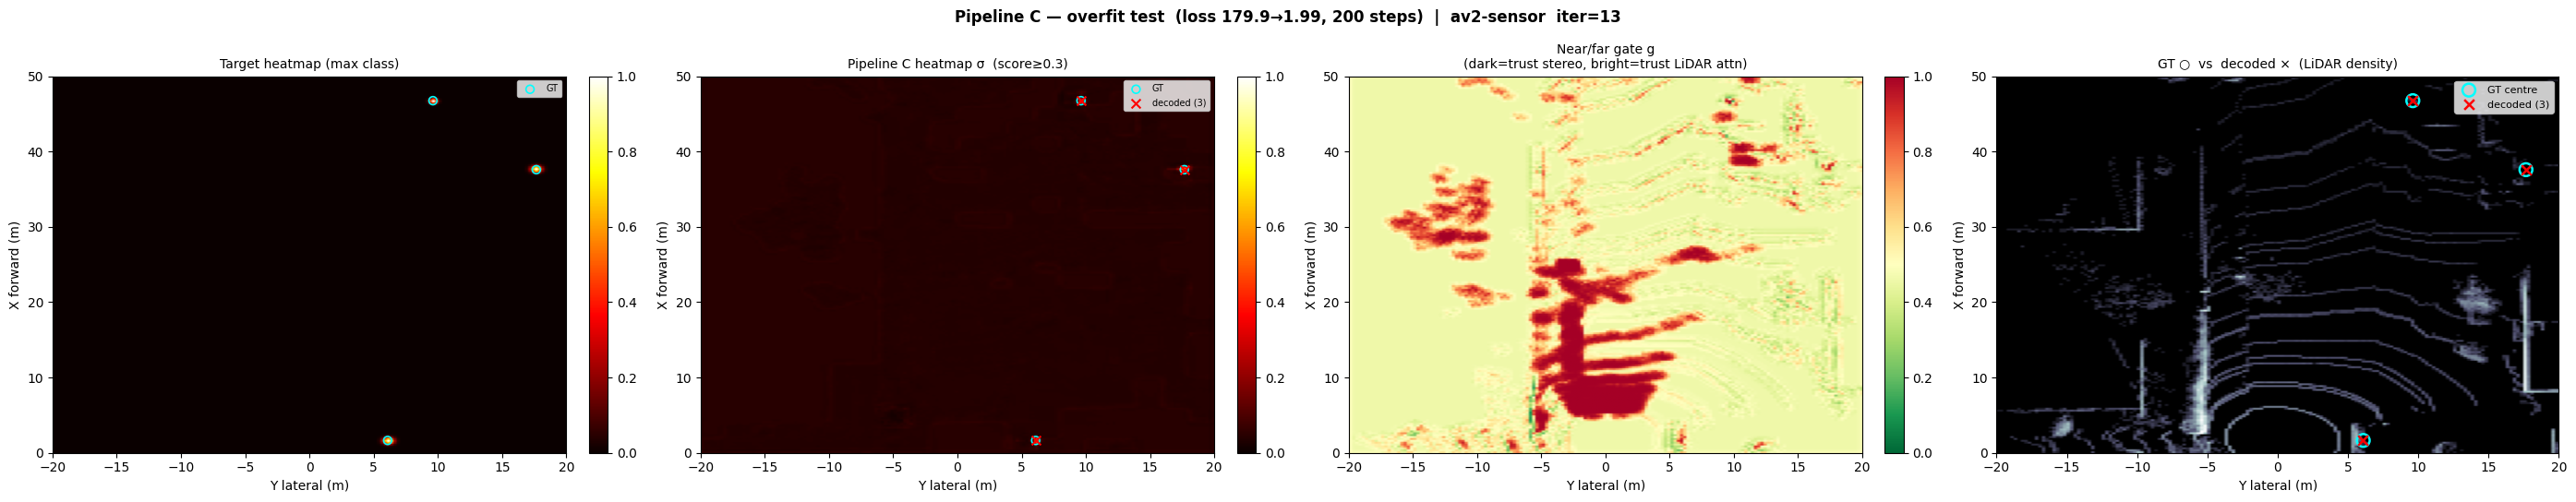

In [11]:
# ── Validation loss on held-out frames (requires checkpoint + dataset) ───────
# from train import split_frames, validate_pipeline_c
#
# CKPT = "checkpoints/pipeline_c_best.pt"
# STEREO_CACHE = "data/stereo_cache"
# dataset_full = Py123dDataset(split_names=["av2-sensor_val"], max_num_scenes=5)
# _, val_frames = split_frames(dataset_full, val_scenes=1)
# pipeline_val = PipelineC(num_classes=3, stereo_cache_root=STEREO_CACHE)
# ckpt = torch.load(CKPT, map_location="cpu")
# pipeline_val.load_state_dict(ckpt["model"])
# val_loss = validate_pipeline_c(pipeline_val, val_frames, device=DEVICE)
# print(f"Pipeline C val loss: {val_loss:.4f}")

# ── Headless gradient check (no dataset needed) ───────────────────────────────
from network import (
    CAMERA_BEV_CHANNELS, LIDAR_BEV_CHANNELS,
    BEVFusionConfig, CrossAttentionFusion, CenterPointHead,
)

_nx_g, _ny_g = G.GRID_SIZE
_cfg_t    = BEVFusionConfig()
_fusion_t = CrossAttentionFusion(_cfg_t, num_heads=4)
_head_t   = CenterPointHead(_cfg_t.out_channels, G.NUM_CLASSES)
_bev_cam_t = torch.randn(1, CAMERA_BEV_CHANNELS, _nx_g, _ny_g)
_bev_lid_t = torch.randn(1, LIDAR_BEV_CHANNELS,  _nx_g, _ny_g)
_fused_t = _fusion_t(_bev_cam_t, _bev_lid_t)
_out_t   = _head_t(_fused_t)
_out_t["heatmap"].sigmoid().sum().backward()
for _name in ("q_proj", "k_proj", "v_proj", "out_proj"):
    _g = getattr(_fusion_t.cross_attn, _name).weight.grad
    assert _g is not None and _g.abs().sum() > 0, f"{_name} has no gradient"
for _i, _p in enumerate(_fusion_t.gate.parameters()):
    if _p.requires_grad:
        assert _p.grad is not None and _p.grad.abs().sum() > 0, f"gate[{_i}] no grad"
print("✓ gradient check passed — attention + gate layers all receive gradients.")

# ── Decode pipeline_overfit (trained in §6) and visualise ────────────────────
# pipeline_overfit, sample, tgt_hm, tgt_off, history are all from the Train cell.
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from evaluation import CenterPointDecoder

SCORE_THR = 0.3

# Capture gate via forward hook
_gate_map = {}
def _grab_gate(m, inp, out): _gate_map["g"] = out[0, 0].detach().cpu().numpy()
_hook = pipeline_overfit.detector.fusion.gate.register_forward_hook(_grab_gate)

pipeline_overfit.eval()
with torch.no_grad():
    _pred = pipeline_overfit(sample, device=DEVICE)
_hook.remove()

_decoder = CenterPointDecoder(score_threshold=SCORE_THR)
_det  = _decoder(_pred["heatmap"].cpu(), _pred["offset"].cpu())[0]
_hm   = _pred["heatmap"].sigmoid().amax(1)[0].cpu().numpy()
_gate = _gate_map.get("g", np.zeros(G.GRID_SIZE))

# Decoded GT centres (same trick as test_overfit.py: scale target to logit range)
_gt_dec = _decoder(tgt_hm * 20 - 10, tgt_off)[0]
_gt_xy  = _gt_dec["boxes_2d"].numpy()     # (N, 2)  ego [x, y]
_det_xy = _det["boxes_2d"].numpy()         # (M, 2)
_det_cls= _det["classes"].numpy()
print(f"GT centres: {len(_gt_xy)}  |  decoded (score≥{SCORE_THR}): {len(_det_xy)}")

# LiDAR density BEV background
_nx, _ny = G.GRID_SIZE
_lidar_grid = np.zeros((_nx, _ny), np.float32)
_pts = sample.lidar_xyz
_pm  = ((_pts[:,0] >= G.X_RANGE[0]) & (_pts[:,0] < G.X_RANGE[1]) &
         (_pts[:,1] >= G.Y_RANGE[0]) & (_pts[:,1] < G.Y_RANGE[1]))
np.add.at(_lidar_grid,
          (((_pts[_pm,0]-G.X_RANGE[0])/G.BEV_RES_M).astype(int),
           ((_pts[_pm,1]-G.Y_RANGE[0])/G.BEV_RES_M).astype(int)), 1.0)
_extent = [G.Y_RANGE[0], G.Y_RANGE[1], G.X_RANGE[0], G.X_RANGE[1]]

def _bev(ax, feat, title, cmap, vmin=None, vmax=None, gt=None):
    im = ax.imshow(feat, origin="lower", cmap=cmap, aspect="auto",
                   extent=_extent, vmin=vmin, vmax=vmax)
    if gt is not None and len(gt):
        ax.scatter(gt[:,1], gt[:,0], s=40, facecolors="none",
                   edgecolors="cyan", lw=1.2, label="GT", zorder=3)
        ax.legend(loc="upper right", fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Y lateral (m)"); ax.set_ylabel("X forward (m)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 4-panel figure
fig, ax = plt.subplots(1, 4, figsize=(28, 5.5))
fig.suptitle(
    f"Pipeline C — overfit test  (loss {history[0]:.1f}→{history[-1]:.2f}, "
    f"{len(history)} steps)  |  "
    f"{sample.dataset}  iter={sample.iteration}",
    fontsize=12, fontweight="bold",
)

# Panel 0: target heatmap
_bev(ax[0], tgt_hm[0].amax(0).numpy(),
     "Target heatmap (max class)", "hot", gt=_gt_xy)

# Panel 1: learned heatmap after overfit
_bev(ax[1], _hm,
     f"Pipeline C heatmap σ  (score≥{SCORE_THR})", "hot", vmin=0, vmax=1,
     gt=_gt_xy)
if len(_det_xy):
    ax[1].scatter(_det_xy[:,1], _det_xy[:,0], s=50, c="red", marker="x",
                  lw=1.5, label=f"decoded ({len(_det_xy)})", zorder=4)
    ax[1].legend(loc="upper right", fontsize=7)

# Panel 2: learned near/far gate
_bev(ax[2], _gate,
     "Near/far gate g\n(dark=trust stereo, bright=trust LiDAR attn)",
     "RdYlGn_r", vmin=0, vmax=1)

# Panel 3: GT ○ vs decoded × on the LiDAR density BEV
ax[3].imshow(np.log1p(_lidar_grid), origin="lower", cmap="bone",
             aspect="auto", extent=_extent)
if len(_gt_xy):
    ax[3].scatter(_gt_xy[:,1], _gt_xy[:,0], s=100, facecolors="none",
                  edgecolors="cyan", lw=1.8, label="GT centre", zorder=3)
if len(_det_xy):
    ax[3].scatter(_det_xy[:,1], _det_xy[:,0], s=60, c="red", marker="x",
                  lw=1.8, label=f"decoded ({len(_det_xy)})", zorder=4)
ax[3].set_title(f"GT ○  vs  decoded ×  (LiDAR density)", fontsize=10)
ax[3].set_xlabel("Y lateral (m)"); ax[3].set_ylabel("X forward (m)")
ax[3].legend(loc="upper right", fontsize=8)

plt.tight_layout()
_save = Path("docs/img/pipeline_c_test_output.png")
_save.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_save, dpi=120, bbox_inches="tight")
print(f"Figure saved → {_save}")
plt.show()
